In [60]:
#Inicialização de dependências das bibliotecas:
import subprocess

def instalar_dependencias():
    subprocess.call(['pip','install','-r','requirements.txt'])

if __name__ == "__main__":
    instalar_dependencias()
    print('Dependências instaladas')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Importando o modulo para processamento das variáveis categóricas em vetores com 0 e 1 para n categorias
from sklearn.preprocessing import OneHotEncoder

Dependências instaladas


In [61]:
dataset = pd.read_csv('NHNES.csv')

In [62]:
dataset.columns

Index(['SEQN', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060',
       'DPQ070', 'DPQ080', 'DPQ090', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1',
       'DMDEDUC', 'INDFMINC', 'PAG_MINW', 'ADHERENCE', 'HEI2015C1_TOTALVEG',
       'HEI2015C2_GREEN_AND_BEAN', 'HEI2015C3_TOTALFRUIT',
       'HEI2015C4_WHOLEFRUIT', 'HEI2015C5_WHOLEGRAIN', 'HEI2015C6_TOTALDAIRY',
       'HEI2015C7_TOTPROT', 'HEI2015C8_SEAPLANT_PROT', 'HEI2015C9_FATTYACID',
       'HEI2015C10_SODIUM', 'HEI2015C11_REFINEDGRAIN', 'HEI2015C12_SFAT',
       'HEI2015C13_ADDSUG', 'HEI2015_TOTAL_SCORE', 'PHQ9', 'PHQ9_CLASS',
       'RIDAGEYR_CLASS'],
      dtype='object')

In [63]:
df = dataset[['SEQN','RIAGENDR', 'RIDRETH1','DMDEDUC', 'INDFMINC','PHQ9']]

df.head()

,SEQN,RIAGENDR,RIDRETH1,DMDEDUC,INDFMINC,PHQ9
0,31131,2,4,4,11.0,0.0
1,31132,1,3,5,11.0,0.0
2,31134,1,3,3,12.0,0.0
3,31139,2,2,3,11.0,4.0
4,31143,1,3,4,11.0,6.0


In [64]:
print(df.isnull().sum()) #Verificando a existência de nulos antes da aplicação dos tratamentos e modelo

SEQN        0
RIAGENDR    0
RIDRETH1    0
DMDEDUC     0
INDFMINC    0
PHQ9        0
dtype: int64


Vamos utilizar, primeiramente, um modelo baseado em variáveis sobre a pessoa (renda, gênero, idade, etc) e avaliar a performance desse modelo. 

Inicialmente vamos aplicar uma consideração que pessoas com sintomas leves ou graves serão considerados classe 1 e sem sintomas como classe 0

Nosso intuito é entender se, dado uma série de características sobre a pessoa, teremos como supor a incidência de um caso depressivo na mesma?

In [65]:
def mapa_valores(x):
    if x < 5:
        return 0
    else:
        return 1
    
df['PHQ9_CLASS'] = df['PHQ9'].map(lambda x: mapa_valores(x))

C:\Users\albino\AppData\Local\Temp\ipykernel_21676\1084600746.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PHQ9_CLASS'] = df['PHQ9'].map(lambda x: mapa_valores(x))


In [66]:
df.groupby('PHQ9_CLASS')['SEQN'].count()

PHQ9_CLASS
0    3706
1     996
Name: SEQN, dtype: int64

<BarContainer object of 2 artists>

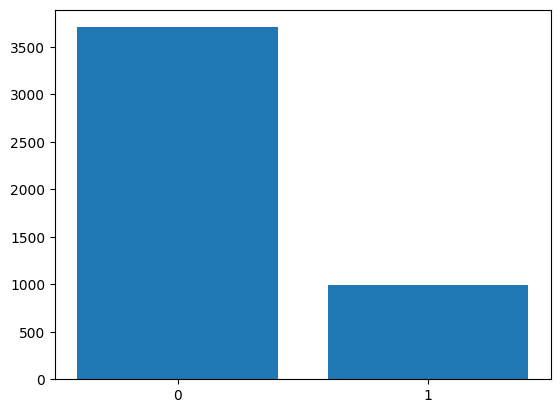

In [67]:
plt.bar(['0','1'],df.groupby('PHQ9_CLASS')['SEQN'].count())

In [68]:
#Alguns parâmetros importantes:

#Handle_unknown -> O que fazer com dados faltantes, nesse caso não temos esse problema
#sparse_outpu -> não queremos uma matriz esparsa
#set_output(transform = 'pandas') -> queremos o resultado como um dataframe

ohe = OneHotEncoder(
    handle_unknown='ignore'
    ,sparse_output=False
).set_output(transform='pandas')

In [69]:
df[['RIAGENDR', 'RIDRETH1', 'DMDEDUC', 'INDFMINC']]

,RIAGENDR,RIDRETH1,DMDEDUC,INDFMINC
0,2,4,4,11.0
1,1,3,5,11.0
2,1,3,3,12.0
3,2,2,3,11.0
4,1,3,4,11.0
...,...,...,...,...
4697,2,5,2,3.0
4698,2,1,1,8.0
4699,1,4,4,2.0
4700,1,3,4,7.0


In [70]:
ohetransform = ohe.fit_transform(df[['RIAGENDR', 'RIDRETH1', 'DMDEDUC', 'INDFMINC']])

In [71]:
ohetransform.columns

Index(['RIAGENDR_1', 'RIAGENDR_2', 'RIDRETH1_1', 'RIDRETH1_2', 'RIDRETH1_3',
       'RIDRETH1_4', 'RIDRETH1_5', 'DMDEDUC_1', 'DMDEDUC_2', 'DMDEDUC_3',
       'DMDEDUC_4', 'DMDEDUC_5', 'DMDEDUC_9', 'INDFMINC_1.0', 'INDFMINC_2.0',
       'INDFMINC_3.0', 'INDFMINC_4.0', 'INDFMINC_5.0', 'INDFMINC_6.0',
       'INDFMINC_7.0', 'INDFMINC_8.0', 'INDFMINC_9.0', 'INDFMINC_10.0',
       'INDFMINC_11.0', 'INDFMINC_12.0', 'INDFMINC_13.0', 'INDFMINC_77.0',
       'INDFMINC_99.0'],
      dtype='object')

In [72]:
print(ohetransform.isna().sum()) #Verificando a existência de nulos antes da aplicação dos tratamentos e modelo

RIAGENDR_1       0
RIAGENDR_2       0
RIDRETH1_1       0
RIDRETH1_2       0
RIDRETH1_3       0
RIDRETH1_4       0
RIDRETH1_5       0
DMDEDUC_1        0
DMDEDUC_2        0
DMDEDUC_3        0
DMDEDUC_4        0
DMDEDUC_5        0
DMDEDUC_9        0
INDFMINC_1.0     0
INDFMINC_2.0     0
INDFMINC_3.0     0
INDFMINC_4.0     0
INDFMINC_5.0     0
INDFMINC_6.0     0
INDFMINC_7.0     0
INDFMINC_8.0     0
INDFMINC_9.0     0
INDFMINC_10.0    0
INDFMINC_11.0    0
INDFMINC_12.0    0
INDFMINC_13.0    0
INDFMINC_77.0    0
INDFMINC_99.0    0
dtype: int64


In [73]:
ohetransform = ohetransform.reset_index(names=['SEQN'])

base = ohetransform.join(df[['SEQN','PHQ9_CLASS']], lsuffix='SEQN', rsuffix='SEQN', how='inner')


In [74]:
#dataset_treino -> 
# Variáveis categóricas de input -> 'RIAGENDR', 'RIDAGEYR_CLASS', 'RIDRETH1', 'DMDEDUC', 'INDFMINC'
# Variável output de interesse ->  'PHQ9_CLASS'

X = base[['RIAGENDR_1', 'RIAGENDR_2','RIDRETH1_1', 'RIDRETH1_2', 'RIDRETH1_3', 'RIDRETH1_4', 'RIDRETH1_5',
       'DMDEDUC_1', 'DMDEDUC_2', 'DMDEDUC_3', 'DMDEDUC_4', 'DMDEDUC_5',
       'DMDEDUC_9', 'INDFMINC_1.0', 'INDFMINC_2.0', 'INDFMINC_3.0',
       'INDFMINC_4.0', 'INDFMINC_5.0', 'INDFMINC_6.0', 'INDFMINC_7.0',
       'INDFMINC_8.0', 'INDFMINC_9.0', 'INDFMINC_10.0', 'INDFMINC_11.0',
       'INDFMINC_12.0', 'INDFMINC_13.0', 'INDFMINC_77.0', 'INDFMINC_99.0']]
Y = base[['PHQ9_CLASS']]

Aqui vale a ressalva que nossos valores estão bastante desbalanceados!

Como podemos lidar com isso?

- Existem métodos que podemos aplicar para equilibrar nossas amostras de treino e teste. Porém nosso primeiro teste será considerando que nossa amostra está balanceada e pode ser utilizada dentro de um modelo de regressão logística

Nosso primeiro passo será dividir os dados em amostras de <b>Treino</b> e <b>Teste</b> 

PHQ9_CLASS
0    2600
1     691
Name: index, dtype: int64


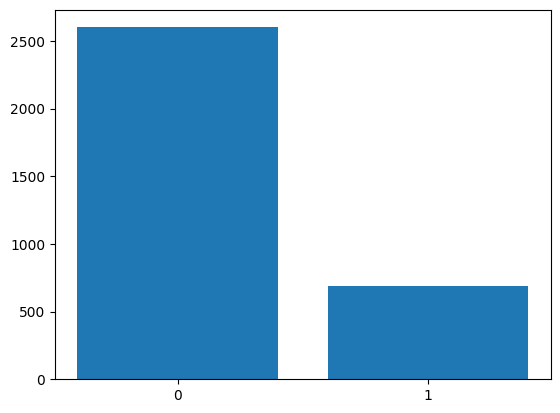

In [75]:

x_treino, x_teste, y_treino, y_teste = train_test_split( X , Y, test_size = 0.3, random_state = 123456)

y_treino_grafico = y_treino.reset_index()

plt.bar(['0','1'],y_treino_grafico.groupby('PHQ9_CLASS')['index'].count()) #Muito desbalanceado!    
print(y_treino_grafico.groupby('PHQ9_CLASS')['index'].count())

In [76]:

classifier = LogisticRegression(random_state=42)

classifier.fit(x_treino, y_treino)

C:\Users\albino\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(random_state=42)

In [77]:
y_predito = classifier.predict(x_teste)

In [78]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_teste, y_predito, labels = ['0', '1'])


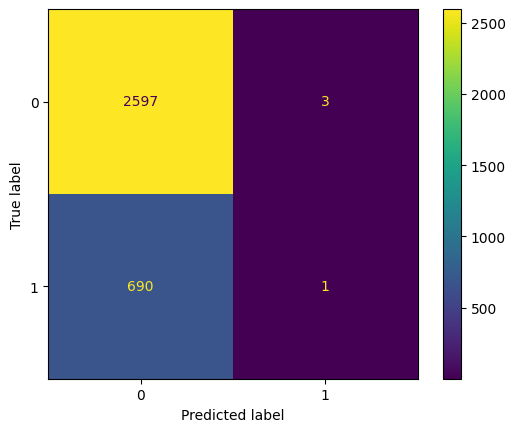

In [79]:
ConfusionMatrixDisplay.from_estimator(classifier, x_treino, y_treino)

In [80]:
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_teste, y_predito)
precision = precision_score(y_teste, y_predito)
recall = recall_score(y_teste, y_predito)
f1 = f1_score(y_teste, y_predito)

print(f"Acurácia: {accuracy*100:.2f}% | Precisão: {precision*100:.2f}% |  Recall: {recall*100:.2f}% | F1 Score: {f1*100:.2f}%")

Acurácia: 78.31% | Precisão: 33.33% |  Recall: 0.33% | F1 Score: 0.65%


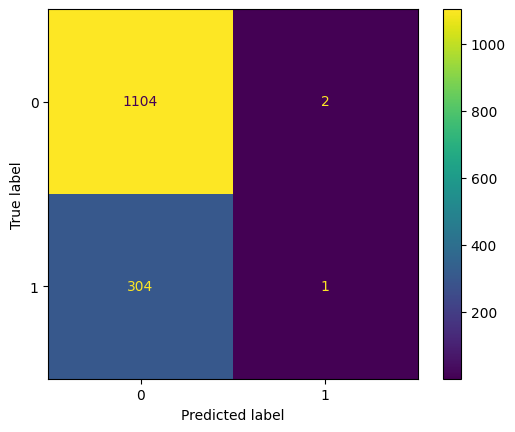

In [81]:
ConfusionMatrixDisplay.from_predictions(y_teste, y_predito)

Nosso modelo performou muito mal, não conseguiu capturar os parâmetros atrelados com o sintoma para a classe 1.

Vamos ter que abordar alguns outros pontos dentro da nossa análise: Primeiro, tentar realizar uma amostra mais balanceada de dados.

In [82]:
classe_0 = base[base['PHQ9_CLASS'] == 0].count()
classe_1 = base[base['PHQ9_CLASS'] == 1].count()


total = classe_0['SEQNSEQN'][0] + classe_1['SEQNSEQN'][0]


C:\Users\albino\AppData\Local\Temp\ipykernel_21676\244492585.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = classe_0['SEQNSEQN'][0] + classe_1['SEQNSEQN'][0]


In [83]:
#No dataset completo temos uma proporção de 4 para 1 aproximadamente. Temos que tratar esse desbalanceamento no input do modelo logístico 
#ou corremos o risco, como visto acima, de não conseguir capturar o comportamento de uma classe

print(f"Classe 0: {classe_0['SEQNSEQN'][0]*100/total:.0f} | Classe 1:  {classe_1['SEQNSEQN'][0]*100/total:.0f}") 

Classe 0: 79 | Classe 1:  21


C:\Users\albino\AppData\Local\Temp\ipykernel_21676\3575492275.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Classe 0: {classe_0['SEQNSEQN'][0]*100/total:.0f} | Classe 1:  {classe_1['SEQNSEQN'][0]*100/total:.0f}")


 <b> Racional de cálculo </b>

classes desbalanceadas 
 
Achar qual classe k_i tem menos valores e quantos são

Sortear aleatoriamente, dentro dessa série, N valores que façam com que Nk_i (número de registros em k_i) seja igual a Nk_j (registros em k_j)

In [84]:
def under_sampler(dataset, target, seed=42):
    #dataset -> conjunto total de dados a sofrer undersample
    #seed -> número para gerador de número aleatório (opcional)
    #target -> variáveis para serem aferidas (k_i)

    #Agrupa o dataset para contar a coluna alvo, já ordenando pelo índice
    sample = dataset.groupby(target).count().sort_index()
    
    #idxmin retorna qual a categoria tem o menor número de registros
    min_class = sample.idxmin()
    
    #retorna o número de registros na menor classe
    min_sample =  sample.min()
    
    print(f'Menor classe: {min_class[0]} com {min_sample[0]} registros' )

    undersampled = []
    
    for class_value in sample.index:

        #filtrar o dataset para a classe
        class_data = dataset[dataset[target] == class_value]

        if len(class_data) > min_sample[0]:

            sampled_data = class_data.sample(n=min_sample[0], random_state = seed)
        
        else:
            
            sampled_data = class_data

        undersampled.append(sampled_data)

    undersampled_df = pd.concat(undersampled)
    
    return undersampled_df 


In [85]:
dataset_treino = base.sample(frac=0.8, random_state=42)

In [86]:
dataset_treino

,SEQNSEQN,RIAGENDR_1,RIAGENDR_2,RIDRETH1_1,RIDRETH1_2,RIDRETH1_3,RIDRETH1_4,RIDRETH1_5,DMDEDUC_1,DMDEDUC_2,...,INDFMINC_8.0,INDFMINC_9.0,INDFMINC_10.0,INDFMINC_11.0,INDFMINC_12.0,INDFMINC_13.0,INDFMINC_77.0,INDFMINC_99.0,SEQNSEQN,PHQ9_CLASS
4154,4154,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,40291,0
2468,2468,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36644,0
2269,2269,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36197,1
497,497,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,32241,1
3312,3312,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38482,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,3044,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,37885,0
3068,3068,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,37934,0
1120,1120,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33715,0
4190,4190,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,40363,0


In [87]:
dataset_treino.groupby('PHQ9_CLASS')['SEQNSEQN'].count()

,SEQNSEQN,SEQNSEQN
PHQ9_CLASS,,
0,2961,2961
1,801,801


In [88]:
dataset_rebalanceado = under_sampler(dataset_treino, 'PHQ9_CLASS') #Esperado um dataset com 1602 linhas balanceadas

dataset_rebalanceado

Menor classe: 1 com 801 registros


C:\Users\albino\AppData\Local\Temp\ipykernel_21676\646077142.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Menor classe: {min_class[0]} com {min_sample[0]} registros' )
C:\Users\albino\AppData\Local\Temp\ipykernel_21676\646077142.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if len(class_data) > min_sample[0]:
C:\Users\albino\AppData\Local\Temp\ipykernel_21676\646077142.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.i

,SEQNSEQN,RIAGENDR_1,RIAGENDR_2,RIDRETH1_1,RIDRETH1_2,RIDRETH1_3,RIDRETH1_4,RIDRETH1_5,DMDEDUC_1,DMDEDUC_2,...,INDFMINC_8.0,INDFMINC_9.0,INDFMINC_10.0,INDFMINC_11.0,INDFMINC_12.0,INDFMINC_13.0,INDFMINC_77.0,INDFMINC_99.0,SEQNSEQN,PHQ9_CLASS
2155,2155,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35947,0
2865,2865,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37515,0
2599,2599,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36918,0
3375,3375,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,38615,0
2791,2791,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,37363,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1658,1658,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34886,1
516,516,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,32286,1
1277,1277,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34060,1
2336,2336,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,36335,1


PHQ9_CLASS
0    801
1    801
Name: SEQNSEQN, dtype: int64


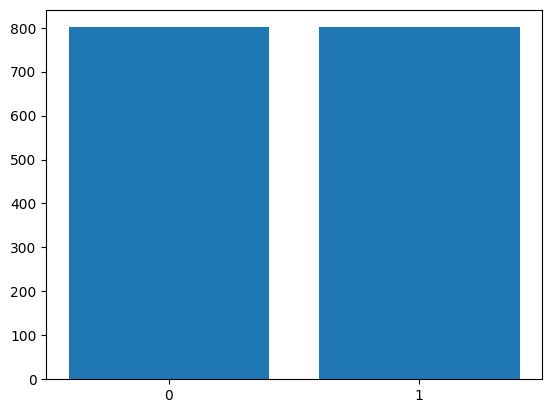

In [89]:
categorias = dataset_rebalanceado.groupby('PHQ9_CLASS')['SEQNSEQN'].count()
plt.bar(['0','1'],categorias.iloc[:,0]) #Muito desbalanceado!    
print(categorias.iloc[:,0])

Vamos criar um novo classificador, agora com os dados rebalanceados dentro do meu dataset.

In [90]:
x_treino_rebalanceado = dataset_rebalanceado[['RIAGENDR_1', 'RIAGENDR_2','RIDRETH1_1', 'RIDRETH1_2', 'RIDRETH1_3', 'RIDRETH1_4', 'RIDRETH1_5',
       'DMDEDUC_1', 'DMDEDUC_2', 'DMDEDUC_3', 'DMDEDUC_4', 'DMDEDUC_5',
       'DMDEDUC_9', 'INDFMINC_1.0', 'INDFMINC_2.0', 'INDFMINC_3.0',
       'INDFMINC_4.0', 'INDFMINC_5.0', 'INDFMINC_6.0', 'INDFMINC_7.0',
       'INDFMINC_8.0', 'INDFMINC_9.0', 'INDFMINC_10.0', 'INDFMINC_11.0',
       'INDFMINC_12.0', 'INDFMINC_13.0', 'INDFMINC_77.0', 'INDFMINC_99.0']]

y_treino_rebalanceado = dataset_rebalanceado[['PHQ9_CLASS']]


In [91]:
classifier_rebalanceado = LogisticRegression(random_state=42)

classifier_rebalanceado.fit(x_treino_rebalanceado, y_treino_rebalanceado)

C:\Users\albino\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(random_state=42)

Para criar o dataset de teste, tiramos todos os indices escolhidos no dataset de treino

In [92]:
teste = base.loc[~base.index.isin(dataset_rebalanceado.index)]

In [93]:
x_teste_rebalanceado = teste[['RIAGENDR_1', 'RIAGENDR_2','RIDRETH1_1', 'RIDRETH1_2', 'RIDRETH1_3', 'RIDRETH1_4', 'RIDRETH1_5',
       'DMDEDUC_1', 'DMDEDUC_2', 'DMDEDUC_3', 'DMDEDUC_4', 'DMDEDUC_5',
       'DMDEDUC_9', 'INDFMINC_1.0', 'INDFMINC_2.0', 'INDFMINC_3.0',
       'INDFMINC_4.0', 'INDFMINC_5.0', 'INDFMINC_6.0', 'INDFMINC_7.0',
       'INDFMINC_8.0', 'INDFMINC_9.0', 'INDFMINC_10.0', 'INDFMINC_11.0',
       'INDFMINC_12.0', 'INDFMINC_13.0', 'INDFMINC_77.0', 'INDFMINC_99.0']]

y_teste_rebalanceado = teste[['PHQ9_CLASS']]

In [94]:
y_predito_rebalanceado = classifier_rebalanceado.predict(x_teste_rebalanceado)

In [95]:
y_predito_rebalanceado

array([0, 0, 0, ..., 1, 1, 0])

In [96]:
accuracy_rebalanceado = accuracy_score(y_teste_rebalanceado, y_predito_rebalanceado)
precision_rebalanceado = precision_score(y_teste_rebalanceado, y_predito_rebalanceado)
recall_rebalanceado = recall_score(y_teste_rebalanceado, y_predito_rebalanceado)
f1_rebalanceado = f1_score(y_teste_rebalanceado, y_predito_rebalanceado)

print(f"Acurácia: {accuracy_rebalanceado*100:.2f}% | Precisão: {precision_rebalanceado*100:.2f}% |  Recall: {recall_rebalanceado*100:.2f}% | F1 Score: {f1_rebalanceado*100:.2f}%")

Acurácia: 58.74% | Precisão: 8.75% |  Recall: 58.97% | F1 Score: 15.24%


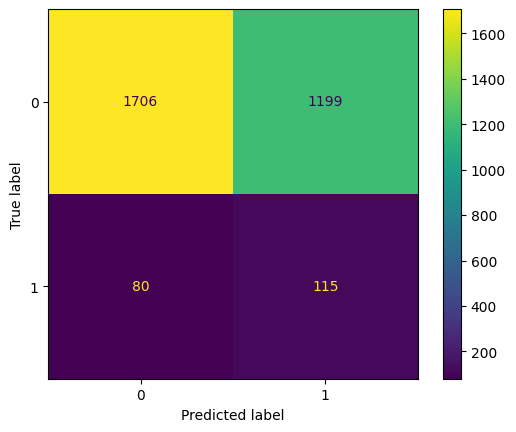

In [97]:
ConfusionMatrixDisplay.from_predictions(y_teste_rebalanceado, y_predito_rebalanceado)

Os resultados do modelo ainda não foram suficientemente satisfatórios

In [98]:
prob = classifier_rebalanceado.predict_proba(x_teste_rebalanceado)

In [99]:
prob

array([[0.74748068, 0.25251932],
       [0.58884684, 0.41115316],
       [0.51003999, 0.48996001],
       ...,
       [0.24069823, 0.75930177],
       [0.44088273, 0.55911727],
       [0.59596277, 0.40403723]])

In [100]:
#Mudando o critério de predizer a classe 1 com base na discrepância
probabilidade_ajustada = []

prob_desbalanceada = classe_1['SEQNSEQN'][0]*100/total

for i in range(len(prob)):

    if prob[i][1]*100 <= prob_desbalanceada:
        resultado = '1'
    else:
        resultado = '0'
    
    probabilidade_ajustada.append(resultado)

C:\Users\albino\AppData\Local\Temp\ipykernel_21676\1319238106.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prob_desbalanceada = classe_1['SEQNSEQN'][0]*100/total


In [101]:
y_teste_rebalanceado.index

Index([   1,    2,    3,    4,    5,    6,    7,    8,    9,   12,
       ...
       4686, 4688, 4690, 4691, 4692, 4694, 4696, 4697, 4699, 4701],
      dtype='int64', length=3100)

In [102]:
y_predito_desbalanceado = pd.DataFrame(data = probabilidade_ajustada , columns = ['PHQ9_CLASS'])
y_predito_desbalanceado['SEQNSEQN'] = y_teste_rebalanceado.index

y_predito_desbalanceado.set_index('SEQNSEQN')

,PHQ9_CLASS
SEQNSEQN,
1,0
2,0
3,0
4,0
5,0
...,...
4694,0
4696,0
4697,0


In [103]:
y_predito_desbalanceado['PHQ9_CLASS'] = y_predito_desbalanceado['PHQ9_CLASS'].astype(int)

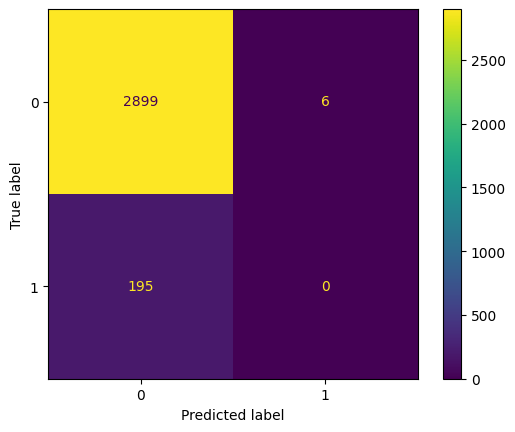

In [104]:
ConfusionMatrixDisplay.from_predictions(y_teste_rebalanceado, y_predito_desbalanceado['PHQ9_CLASS'])

In [105]:
accuracy = accuracy_score(y_teste_rebalanceado, y_predito_desbalanceado.set_index('SEQNSEQN'))
precision = precision_score(y_teste_rebalanceado, y_predito_desbalanceado.set_index('SEQNSEQN'))
recall = recall_score(y_teste_rebalanceado, y_predito_desbalanceado.set_index('SEQNSEQN'))
f1 = f1_score(y_teste_rebalanceado, y_predito_desbalanceado.set_index('SEQNSEQN'))


print(f"Acurácia: {accuracy*100:.2f}% | Precisão: {precision*100:.2f}% |  Recall: {recall*100:.2f}% | F1 Score: {f1*100:.2f}%")

Acurácia: 93.52% | Precisão: 0.00% |  Recall: 0.00% | F1 Score: 0.00%


In [106]:
from sklearn.ensemble import RandomForestClassifier

In [108]:
clf = RandomForestClassifier(random_state=42)

clf.fit(x_treino_rebalanceado, y_treino_rebalanceado)

C:\Users\albino\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [109]:
y_predito_rf = clf.predict(x_teste_rebalanceado)

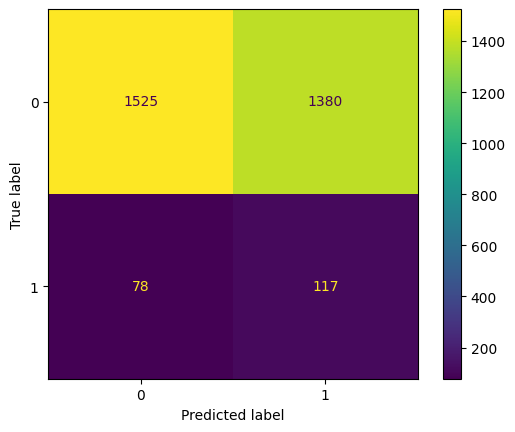

In [110]:
ConfusionMatrixDisplay.from_predictions(y_teste_rebalanceado,y_predito_rf)

In [111]:
accuracy = accuracy_score(y_teste_rebalanceado, y_predito_rf)
precision = precision_score(y_teste_rebalanceado, y_predito_rf)
recall = recall_score(y_teste_rebalanceado, y_predito_rf)
f1 = f1_score(y_teste_rebalanceado, y_predito_rf)


print(f"Acurácia: {accuracy*100:.2f}% | Precisão: {precision*100:.2f}% |  Recall: {recall*100:.2f}% | F1 Score: {f1*100:.2f}%")

Acurácia: 52.97% | Precisão: 7.82% |  Recall: 60.00% | F1 Score: 13.83%


In [119]:
import sklearn.metrics as metrics

classifier_rebalanceado.summary()

AttributeError: 'LogisticRegression' object has no attribute 'summary'

In [122]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
modelo = smf.glm(formula='PHQ9_CLASS ~ RIAGENDR + RIDRETH1 + DMDEDUC + INDFMINC',
                 data = dataset
                 , family = sm.families.Binomial()).fit()


In [123]:
print(modelo.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             PHQ9_CLASS   No. Observations:                 4702
Model:                            GLM   Df Residuals:                     4697
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                   -inf
Date:                Tue, 17 Sep 2024   Deviance:                       29003.
Time:                        14:41:24   Pearson chi2:                 7.78e+03
No. Iterations:                     6   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1229      0.149     -7.537      0.0

C:\Users\albino\AppData\Roaming\Python\Python312\site-packages\statsmodels\genmod\generalized_linear_model.py:1891: RuntimeWarning: invalid value encountered in scalar subtract
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))
